In [1]:
import os
os.environ['PISA_RESOURCES'] = "/data/user/akatil/electron_neutrino/for_real/PISA/wg-oscillations-fridge/analysis/upgrade_std_osc/"
os.environ['PISA_RESOURCES'] += os.pathsep + "/data/user/akatil/electron_neutrino/for_real/PISA/wg-oscillations-fridge/analysis/"
os.environ['PISA_RESOURCES'] += os.pathsep + "/data/ana/LE/"
os.environ['PISA_RESOURCES'] += os.pathsep + "/data/user/mliubarska/osc/pisa2_osc/pisa_examples/resources/"

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
from uncertainties import unumpy as unp
import matplotlib.pyplot as plt
import pickle
import pisa
import copy
from scipy.special import erfcinv, erfc
import pandas as pd
import os

from pisa.core.pipeline import Pipeline
from pisa.core.distribution_maker import DistributionMaker
from pisa.core.detectors import Detectors
from pisa import FTYPE, ureg
from pisa.utils.fileio import from_file, to_file
from pisa.core.map import MapSet
from pisa.analysis.analysis import Analysis
from pisa.analysis.analysis import update_param_values, update_param_values_detector
from pisa.utils import stats

fatal: detected dubious ownership in repository at '/mnt/ceph1-npx/user/mliubarska/osc/pisa2_osc'
To add an exception for this directory, call:

	git config --global --add safe.directory /mnt/ceph1-npx/user/mliubarska/osc/pisa2_osc
<< PISA is running in double precision (FP64) mode; numba is running on CPU (single core) >>


In [3]:
params = {'legend.fontsize': 18,
          'figure.figsize': (9, 9*0.618),
          'axes.labelsize': 18,
          'axes.titlesize': 18,
          'xtick.labelsize': 18,
          'ytick.labelsize': 18}
plt.rcParams.update(params)

# ONE BIN

In [4]:
%%time

p1_nu_NO_1 = Pipeline("settings/pipeline/pipeline_upgrade_neutrinos_std_osc_NO_nue.cfg")
p1_nu_IO_1 = Pipeline("settings/pipeline/pipeline_upgrade_neutrinos_std_osc_IO_nue.cfg")

template_maker_NO_1 = DistributionMaker(p1_nu_NO_1)
template_maker_IO_1 = DistributionMaker(p1_nu_IO_1)

[ WARNING] /data/user/mliubarska/osc/pisa2_conda_env/lib/python3.10/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")

[ WARNING] /data/user/mliubarska/osc/pisa2_conda_env/lib/python3.10/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")

CPU times: user 1min 10s, sys: 1.55 s, total: 1min 12s
Wall time: 1min 12s


In [6]:
events_NO = unp.nominal_values(template_maker_NO_1.get_outputs(return_sum=True)[0]['total'].hist)
events_IO = unp.nominal_values(template_maker_IO_1.get_outputs(return_sum=True)[0]['total'].hist)

sigma_NO = np.sqrt(unp.nominal_values(events_NO))
sigma_IO = np.sqrt(unp.nominal_values(events_IO))

significance = np.abs((events_IO - events_NO)/np.sqrt(events_NO))
print(events_NO.item(), events_IO.item(), significance.item())

15465.938779302594 15427.204049325752 0.3114672507357213


# Percentage of Events

In [7]:
nue = unp.nominal_values(template_maker_NO_1.get_outputs()[0][0]['nue_cc'].hist + 
                        template_maker_NO_1.get_outputs()[0][0]['nuebar_cc'].hist)
numu = unp.nominal_values(template_maker_NO_1.get_outputs()[0][0]['numu_cc'].hist + 
                        template_maker_NO_1.get_outputs()[0][0]['numubar_cc'].hist)
nutau = unp.nominal_values(template_maker_NO_1.get_outputs()[0][0]['nutau_cc'].hist + 
                        template_maker_NO_1.get_outputs()[0][0]['nutaubar_cc'].hist)

nc = unp.nominal_values(template_maker_NO_1.get_outputs()[0][0]['nue_nc'].hist + 
                        template_maker_NO_1.get_outputs()[0][0]['nuebar_nc'].hist +
                        template_maker_NO_1.get_outputs()[0][0]['numu_nc'].hist + 
                        template_maker_NO_1.get_outputs()[0][0]['numubar_nc'].hist +
                        template_maker_NO_1.get_outputs()[0][0]['nutau_nc'].hist + 
                        template_maker_NO_1.get_outputs()[0][0]['nutaubar_nc'].hist)

In [8]:
fraction = np.array([nue.item()/events_NO.item(), numu.item()/events_NO.item(), nutau.item()/events_NO.item(), nc.item()/events_NO.item()])
events = np.array([nue.item(), numu.item(), nutau.item(), nc.item()])

In [9]:
uncertainty = fraction*np.sqrt((1/events+(1/events_NO.item())))

In [10]:
events_NO.item(), fraction, events, uncertainty

(15465.938779302594,
 array([0.56852553, 0.21756635, 0.03537348, 0.17853463]),
 array([8792.78111529, 3364.86782602,  547.08414168, 2761.20569632]),
 array([0.00759334, 0.00413861, 0.00153886, 0.00368845]))

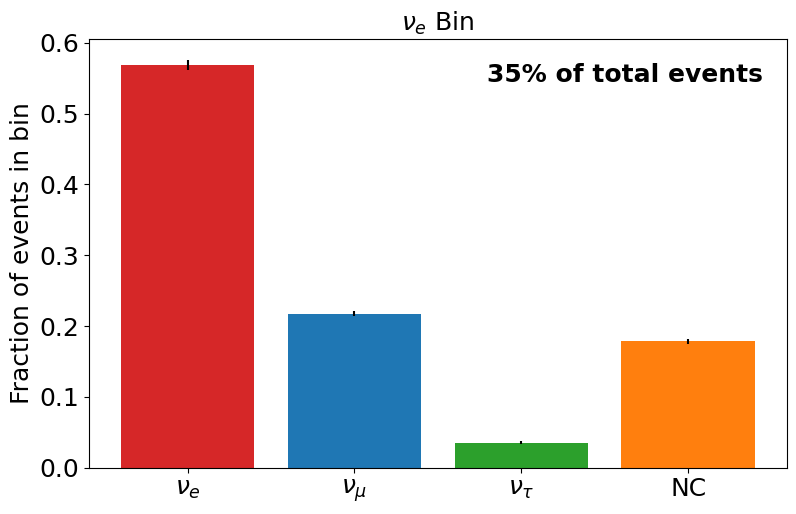

In [11]:
fig, ax = plt.subplots()

event_types = [r'$\nu_e$', r'$\nu_\mu$', r'$\nu_\tau$', 'NC']
#counts = [nue.item()/events_NO.item(), numu.item()/events_NO.item(), nutau.item()/events_NO.item(), nc.item()/events_NO.item()]
bar_labels = ['red', 'blue', 'green', 'orange']
bar_colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange']

ax.bar(event_types, fraction, yerr=uncertainty, color=bar_colors)

ax.set_ylabel('Fraction of events in bin')
ax.set_title(r'$\nu_e$ Bin')
ax.text(0.57, 0.9, '35% of total events', transform=ax.transAxes,
        fontsize=18, fontweight='bold')
#ax.set_title('Nominal Bin')
#ax.legend(title='Fruit color')
plt.savefig('nue_bin_fractional_events_count_based_analysis.pdf', bbox_inches='tight', dpi=200)

In [11]:
filename = "./csv_files/reco_significance_values_moved_nc_cut.csv"

if os.path.exists(filename):
    df_new = pd.DataFrame({
        'events_NO': [events_NO.item()],
        'events_IO': [events_IO.item()],
        'significance': [significance.item()]
    })

    df_new.to_csv(filename, mode='a', header=False, index=False)
else:
    df_new = pd.DataFrame({
        'events_NO': [events_NO.item()],
        'events_IO': [events_IO.item()],
        'significance': [significance.item()]
    })

    df_new.to_csv(filename, mode='a', header=False, index=False)

print("Significance value saved.")

In [12]:
df_read = pd.read_csv(filename, header=None)
print(df_read)

              0             1         2
0  44720.178963  44764.198489  0.208158
1  15465.938779  15427.204049  0.311467
2  15489.637001  15535.954878  0.372159
3  13405.039146  13441.145983  0.311857


In [7]:
df_read = pd.read_csv(filename, header=None)
print(df_read)

              0             1         2
0  44720.178963  44764.198489  0.208158
1  15465.938779  15427.204049  0.311467
2  15489.637001  15535.954878  0.372159
3  13405.039146  13441.145983  0.311857


In [13]:
df_read[2][0]

0.208158232671846

In [14]:
combined_significance = 0
for i in range(1, 4):
    print(i)
    denom = np.sqrt(np.sum(df_read[0][1] +  df_read[0][2] + df_read[0][3]))
    print(df_read[0][1],  df_read[0][2], df_read[0][3])
    combined_significance += df_read[2][i] * np.sqrt(df_read[0][i])/denom
    print(df_read[2][i], np.sqrt(df_read[0][i])/denom)

1
15465.938779302594 15489.637000789116 13405.03914605756
0.3114672507357213 0.5904584804228658
2
15465.938779302594 15489.637000789116 13405.03914605756
0.3721585684282457 0.5909106825137184
3
15465.938779302594 15489.637000789116 13405.03914605756
0.3118569313942652 0.5497120593437004


In [15]:
df_read[2][0], combined_significance

(0.208158232671846, 0.5752524692215133)

In [16]:
df_read[2][0], combined_significance

(0.208158232671846, 0.5752524692215133)